In [3]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report, 
                              confusion_matrix, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# load data
X_train = pd.read_csv("../data/processed/X_train.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").squeeze()
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

FEATURES = X_train.columns.tolist()

In [4]:
model_lr = LogisticRegression(random_state=42, max_iter=1000)
model_lr.fit(X_train, y_train)
pred_lr = model_lr.predict(X_test)
prob_lr = model_lr.predict_proba(X_test)[:, 1]

print("=" * 50)
print("LOGISTIC REGRESSION")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, pred_lr):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, prob_lr):.3f}")
print("\nFull Report:")
print(classification_report(y_test, pred_lr, target_names=["No semis", "Yes semis"]))

LOGISTIC REGRESSION
Accuracy: 0.976
ROC-AUC:  0.988

Full Report:
              precision    recall  f1-score   support

    No semis       0.97      1.00      0.99        69
   Yes semis       1.00      0.88      0.93        16

    accuracy                           0.98        85
   macro avg       0.99      0.94      0.96        85
weighted avg       0.98      0.98      0.98        85



In [ ]:
model_rf = RandomForestClassifier(
    n_estimators=100, 
    max_depth=5, 
    random_state=42
)
model_rf.fit(X_train, y_train)
pred_rf = model_rf.predict(X_test)
prob_rf = model_rf.predict_proba(X_test)[:, 1]

print("=" * 50)
print("RANDOM FOREST")
print("=" * 50)
print(f"Accuracy: {accuracy_score(y_test, pred_rf):.3f}")
print(f"ROC-AUC:  {roc_auc_score(y_test, prob_rf):.3f}")
print("\Full Report:")
print(classification_report(y_test, pred_rf, target_names=["No semis", "Yes semis"]))

RANDOM FOREST
Accuracy: 0.976
ROC-AUC:  0.991

Reporte completo:
              precision    recall  f1-score   support

    No semis       0.97      1.00      0.99        69
    Sí semis       1.00      0.88      0.93        16

    accuracy                           0.98        85
   macro avg       0.99      0.94      0.96        85
weighted avg       0.98      0.98      0.98        85




Importance of variables:
                   feature  importancia
0           matches_played     0.264156
3                     wins     0.223377
1                goals_for     0.201783
8           win_percentage     0.092199
9          goal_difference     0.070680
7          goals_per_match     0.045802
2            goals_against     0.029029
6       average_attendance     0.028914
5                   losses     0.013482
4                    draws     0.011750
16      confederation_UEFA     0.007055
15     confederation_Other     0.005400
13  confederation_CONMEBOL     0.004647
12  confederation_CONCACAF     0.001375
11       confederation_CAF     0.000295
10       confederation_AFC     0.000055
14       confederation_OFC     0.000000


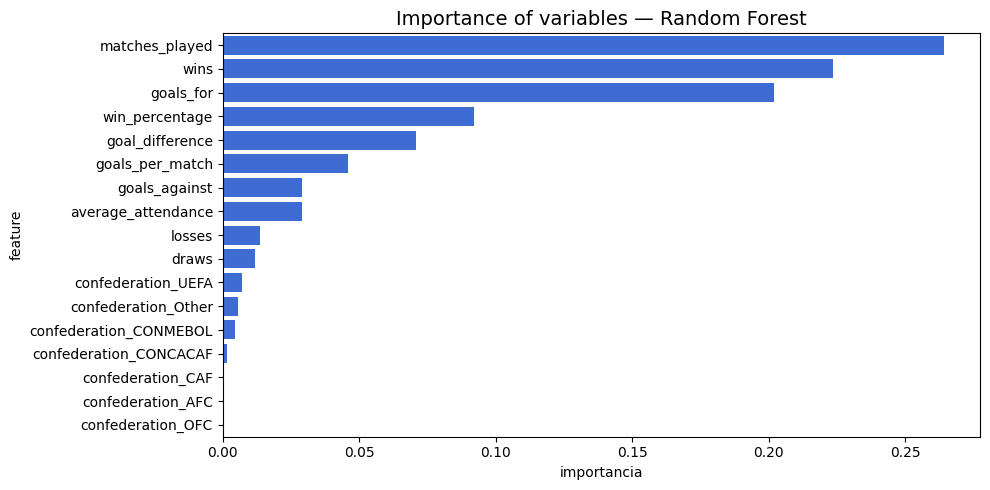

In [8]:
importancias = pd.DataFrame({
    "feature": FEATURES,
    "importancia": model_rf.feature_importances_
}).sort_values("importancia", ascending=False)

print("\nImportance of variables:")
print(importancias)

fig, ax = plt.subplots(figsize=(10, 5))
sns.barplot(data=importancias, x="importancia", y="feature", color="#2563eb", ax=ax)
ax.set_title("Importance of variables — Random Forest", fontsize=14)
plt.tight_layout()
plt.savefig("../outputs/figures/06_variables_importance.png", dpi=150)

In [10]:
acc_lr = accuracy_score(y_test, pred_lr)
acc_rf = accuracy_score(y_test, pred_rf)

if acc_rf >= acc_lr:
    best_model = model_rf
    model_name = "Random Forest"
else:
    best_model = model_rf
    model_name = "Logistic Regression"

joblib.dump(best_model, "../outputs/final_model.pkl")
print(f"\n✅ Selected model: {model_name}")
print(f"   Accuracy in test: {max(acc_lr, acc_rf):.3f}")
print(f"   Saved in: outputs/final_model.pkl")


✅ Selected model: Random Forest
   Accuracy in test: 0.976
   Saved in: outputs/final_model.pkl
